# M2 / Nhiệm vụ 10 — So sánh phương án và chọn Final Method

Notebook này chỉ sử dụng artifact **development** của KMeans Baseline, Ward Hierarchical và PCA + KMeans. Nó không nạp dữ liệu, artifact hay kết quả của Final Holdout.

Quy tắc quyết định: cùng 15 snapshot, 8 market features, Global K = 2; ưu tiên Silhouette, Davies–Bouldin, sanity check, ổn định thời gian và Occam’s Razor. Các profile lấy từ `m2-evaluation-*`; schema được chuẩn hóa trong bộ nhớ, không sửa artifact nguồn.

### Bối cảnh thực thi và rào chắn

Notebook chỉ tổng hợp artifact đã có của development; không fit lại mô hình và không đọc dữ liệu holdout. Các biến đường dẫn dưới đây xác định nơi đọc ba phương án, nơi ghi output Task 10 và danh sách 8 feature được khóa trong protocol.

In [1]:
from __future__ import annotations

import hashlib
import json
import shutil
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / 'M2').exists():
    raise RuntimeError('Run this notebook from the repository root.')

M2_DIR = REPO_ROOT / 'M2'
EVAL_ROOT = M2_DIR / 'artifacts'
OUTPUT_DIR = EVAL_ROOT / 'm2-evaluation'
MODEL_TARGET = M2_DIR / 'models' / 'final_selected_model'
NOTEBOOK_RELATIVE_PATH = 'M2/notebooks/10_model_comparison.ipynb'

FEATURES = ['mom_21', 'mom_63', 'mom_126', 'mom_252', 'vol_63', 'mdd_126', 'beta_126', 'liquidity_21']
EXPECTED_SNAPSHOTS = [
    '2023-11-30', '2023-12-29', '2024-01-31', '2024-02-29', '2024-03-29',
    '2024-04-26', '2024-05-31', '2024-06-28', '2024-07-31', '2024-08-30',
    '2024-09-30', '2024-10-31', '2024-11-29', '2024-12-31', '2025-01-24',
]
EXPECTED_PAIRS = list(zip(EXPECTED_SNAPSHOTS[:-1], EXPECTED_SNAPSHOTS[1:]))

METHODS = {
    'KMeans_Baseline': {
        'evaluation_dir': EVAL_ROOT / 'm2-evaluation-kmeans',
        'task_dir': EVAL_ROOT / 'm2-task4-kmeans-baseline-v1',
        'config': REPO_ROOT / 'configs' / 'experiments' / 'm2_market_only_v1.json',
        'complexity': 'Low',
    },
    'Ward_Hierarchical': {
        'evaluation_dir': EVAL_ROOT / 'm2-evaluation-ward',
        'task_dir': EVAL_ROOT / 'm2-task5-ward-v1',
        'config': REPO_ROOT / 'configs' / 'experiments' / 'm2_ward_market_only_v1.json',
        'complexity': 'Medium',
    },
    'PCA_KMeans': {
        'evaluation_dir': EVAL_ROOT / 'm2-evaluation-pca-kmeans',
        'task_dir': EVAL_ROOT / 'm2-task6-pca-kmeans-v1',
        'config': REPO_ROOT / 'configs' / 'experiments' / 'm2_task6_pca.json',
        'complexity': 'High',
    },
}

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
pd.set_option('display.max_columns', 30)

## Bước 1 — Nạp và kiểm định tính toàn vẹn đầu vào

Kiểm tra protocol, Global K, 15 snapshot, 14 cặp tháng, profile và model development.

### Kiểm định protocol và lineage đầu vào

Mỗi config phải cùng `M2_TASK_3_GLOBAL_K_FROZEN`, `K=2`, 8 feature theo đúng thứ tự và 15 snapshot development. Sau đó notebook chỉ đăng ký các file cần đọc: quality summary, profile Task 8, temporal stability, diagnostics K=2, centroid drift, model JSON và config. Nếu bất kỳ file nào thiếu, notebook dừng thay vì tự suy diễn.

In [2]:
def sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open('rb') as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b''):
            digest.update(block)
    return digest.hexdigest()

# Protocol gate: all three configs must prove the shared development contract.
for method, spec in METHODS.items():
    with spec['config'].open(encoding='utf-8') as handle:
        config = json.load(handle)
    clustering = config['clustering']
    assert config['stage'] == 'M2_TASK_3_GLOBAL_K_FROZEN', method
    assert clustering['k'] == 2, method
    assert clustering['features'] == FEATURES, method
    assert config['development_snapshots'] == EXPECTED_SNAPSHOTS, method
    assert config['holdout_policy']['sealed_during_development'] is True, method

# Only development artifact paths are registered below; no holdout path is permitted.
source_manifest = []
for method, spec in METHODS.items():
    for key, path in {
        'quality_summary': spec['evaluation_dir'] / 'quality_summary.csv',
        'cluster_profiles': spec['evaluation_dir'] / 'cluster_profiles.csv',
        'temporal_stability': spec['evaluation_dir'] / 'temporal_stability.csv',
        'diagnostics': spec['task_dir'] / 'diagnostics.csv',
        'centroid_drift': spec['evaluation_dir'] / 'centroid_drift.csv',
        'models': spec['task_dir'] / 'models',
        'config': spec['config'],
    }.items():
        assert path.exists(), f'Missing {method} input: {path}'
        source_manifest.append({'method': method, 'artifact': key, 'path': str(path.relative_to(REPO_ROOT))})

pd.DataFrame(source_manifest)


,method,artifact,path
0,KMeans_Baseline,quality_summary,M2\artifacts\m2-evaluation-kmeans\quality_summ...
1,KMeans_Baseline,cluster_profiles,M2\artifacts\m2-evaluation-kmeans\cluster_prof...
2,KMeans_Baseline,temporal_stability,M2\artifacts\m2-evaluation-kmeans\temporal_sta...
3,KMeans_Baseline,diagnostics,M2\artifacts\m2-task4-kmeans-baseline-v1\diagn...
4,KMeans_Baseline,centroid_drift,M2\artifacts\m2-evaluation-kmeans\centroid_dri...
5,KMeans_Baseline,models,M2\artifacts\m2-task4-kmeans-baseline-v1\models
6,KMeans_Baseline,config,configs\experiments\m2_market_only_v1.json
7,Ward_Hierarchical,quality_summary,M2\artifacts\m2-evaluation-ward\quality_summar...
8,Ward_Hierarchical,cluster_profiles,M2\artifacts\m2-evaluation-ward\cluster_profil...
9,Ward_Hierarchical,temporal_stability,M2\artifacts\m2-evaluation-ward\temporal_stabi...


## Bước 2 — Tổng hợp chỉ số thống kê

Tổng hợp Quality, Temporal Stability, Centroid Drift và Sanity Check; đối chiếu `quality_summary.csv` với diagnostics K=2.

### Chất lượng cụm: cách đọc và đối chiếu

Silhouette là tiêu chí chính, càng cao càng tốt. Davies–Bouldin là xác nhận/tie-breaker, càng thấp càng tốt. Calinski–Harabasz và cluster balance là chỉ số bổ trợ. `quality_summary.csv` là nguồn tổng hợp chính; `diagnostics.csv` được lọc riêng `K=2` để tính thêm độ lệch chuẩn và đối chiếu mean/median/min/max với summary.

In [3]:
QUALITY_COLUMNS = ['silhouette', 'davies_bouldin', 'calinski_harabasz', 'cluster_balance']
QUALITY_SUMMARY_COLUMNS = ['mean', 'median', 'minimum', 'maximum']

quality_summaries: dict[str, pd.DataFrame] = {}
diagnostics_by_method: dict[str, pd.DataFrame] = {}
quality_stats_rows = []

for method, spec in METHODS.items():
    summary = pd.read_csv(spec['evaluation_dir'] / 'quality_summary.csv').set_index('metric')
    assert set(QUALITY_COLUMNS).issubset(summary.index), f'{method}: missing quality metric'
    assert (summary.loc[QUALITY_COLUMNS, 'n_total'] == 15).all(), f'{method}: n_total is not 15'
    assert (summary.loc[QUALITY_COLUMNS, 'n_available'] == 15).all(), f'{method}: n_available is not 15'
    quality_summaries[method] = summary

    diagnostics = pd.read_csv(spec['task_dir'] / 'diagnostics.csv')
    selected = diagnostics.loc[diagnostics['k'].eq(2)].copy()
    selected['snapshot_date'] = selected['snapshot_date'].astype(str)
    assert selected['snapshot_date'].tolist() == EXPECTED_SNAPSHOTS, f'{method}: selected K=2 dates differ'
    assert len(selected) == 15, f'{method}: expected 15 K=2 diagnostic rows'
    diagnostics_by_method[method] = selected

    for metric in QUALITY_COLUMNS:
        actual = selected[metric].astype(float).agg(['median', 'mean', 'min', 'max', 'std'])
        expected = summary.loc[metric]
        crosswalk = {'mean': 'mean', 'median': 'median', 'minimum': 'min', 'maximum': 'max'}
        for summary_column, calculated_column in crosswalk.items():
            assert np.isclose(float(expected[summary_column]), float(actual[calculated_column]), rtol=1e-10, atol=1e-10), (method, metric, summary_column)
        quality_stats_rows.append({
            'method': method, 'metric': metric,
            'median': actual['median'], 'mean': actual['mean'], 'minimum': actual['min'],
            'maximum': actual['max'], 'std': actual['std'], 'n': len(selected),
        })

quality_statistics = pd.DataFrame(quality_stats_rows)
display(quality_statistics)


,method,metric,median,mean,minimum,maximum,std,n
0,KMeans_Baseline,silhouette,0.755722,0.791489,0.636868,0.949859,0.112640,15
1,KMeans_Baseline,davies_bouldin,0.521899,0.514798,0.356337,0.747218,0.107700,15
2,KMeans_Baseline,calinski_harabasz,316.391783,687.889134,160.006764,2046.647682,643.300851,15
3,KMeans_Baseline,cluster_balance,0.067669,0.056407,0.010363,0.094972,0.029321,15
4,Ward_Hierarchical,silhouette,0.755722,0.763118,0.458851,0.943929,0.157756,15
5,Ward_Hierarchical,davies_bouldin,0.534333,0.578858,0.267141,1.093217,0.254492,15
6,Ward_Hierarchical,calinski_harabasz,316.391783,614.645839,118.873252,1882.058299,570.602625,15
7,Ward_Hierarchical,cluster_balance,0.067669,0.080491,0.010292,0.223602,0.067824,15
8,PCA_KMeans,silhouette,0.771666,0.804410,0.659505,0.951234,0.104001,15
9,PCA_KMeans,davies_bouldin,0.515502,0.499010,0.354967,0.716695,0.097468,15


### Hồ sơ cụm và sanity check

Ba file profile Task 8 có cách biểu diễn khác nhau. KMeans dùng hậu tố `_mean`; Ward có sẵn tám cột feature; PCA+KMeans lưu tâm cụm trong JSON `centroid`. Ô dưới chỉ chuẩn hóa chúng trong bộ nhớ về một bảng chung, rồi kiểm tra 15 snapshot × 2 cụm, kích thước cụm tối thiểu và tỷ trọng cụm. Không ghi đè hay sao chép ngược artifact nguồn.

In [4]:
def decode_centroid(value) -> dict:
    if isinstance(value, dict):
        return value
    if pd.isna(value):
        return {}
    decoded = json.loads(value)
    if not isinstance(decoded, dict):
        raise ValueError('centroid must decode to an object')
    return decoded


def normalise_profiles(method: str, path: Path) -> pd.DataFrame:
    raw = pd.read_csv(path).copy()
    required_identity = {'snapshot_date', 'raw_cluster_id', 'aligned_cluster_id', 'size'}
    assert required_identity.issubset(raw.columns), f'{method}: profile identity columns are missing'

    result = raw[['snapshot_date', 'raw_cluster_id', 'aligned_cluster_id', 'size']].copy()
    result['snapshot_date'] = result['snapshot_date'].astype(str)
    result['size'] = pd.to_numeric(result['size'])

    mean_columns = [f'{feature}_mean' for feature in FEATURES]
    if set(mean_columns).issubset(raw.columns):
        for feature, source_column in zip(FEATURES, mean_columns):
            result[feature] = pd.to_numeric(raw[source_column])
        profile_schema = 'evaluation_feature_means'
    elif set(FEATURES).issubset(raw.columns):
        for feature in FEATURES:
            result[feature] = pd.to_numeric(raw[feature])
        profile_schema = 'evaluation_feature_columns'
    elif 'centroid' in raw.columns:
        decoded = raw['centroid'].map(decode_centroid)
        for feature in FEATURES:
            result[feature] = pd.to_numeric(decoded.map(lambda item: item.get(feature)))
        profile_schema = 'evaluation_centroid_json'
    else:
        raise ValueError(f'{method}: no supported 8-feature profile representation')

    result['size_ratio'] = result['size'] / result.groupby('snapshot_date')['size'].transform('sum')
    result.insert(0, 'method', method)
    result.insert(5, 'profile_schema', profile_schema)
    assert result[FEATURES].notna().all().all(), f'{method}: profile feature missing after normalization'
    return result

profiles_by_method = {}
profile_rows = []
for method, spec in METHODS.items():
    profile = normalise_profiles(method, spec['evaluation_dir'] / 'cluster_profiles.csv')
    assert sorted(profile['snapshot_date'].unique().tolist()) == EXPECTED_SNAPSHOTS, f'{method}: profile dates differ'
    assert len(profile) == 30, f'{method}: profile must contain 15 x 2 rows'
    assert (profile.groupby('snapshot_date').size() == 2).all(), f'{method}: not exactly two clusters each snapshot'
    assert (profile.groupby('snapshot_date')['aligned_cluster_id'].nunique() == 2).all(), f'{method}: aligned ids are not unique'
    profiles_by_method[method] = profile
    profile_rows.append({
        'method': method,
        'profile_input': str((spec['evaluation_dir'] / 'cluster_profiles.csv').relative_to(REPO_ROOT)),
        'profile_schema_detected': profile['profile_schema'].iloc[0],
        'snapshot_count': profile['snapshot_date'].nunique(),
        'cluster_rows': len(profile),
        'minimum_cluster_size': int(profile['size'].min()),
        'median_cluster_balance': float((profile.groupby('snapshot_date')['size'].min() / profile.groupby('snapshot_date')['size'].max()).median()),
        'degenerate_cluster_under_5': bool((profile['size'] < 5).any()),
        'sanity_status': 'PASS' if not (profile['size'] < 5).any() else 'FAIL',
    })

profile_sanity = pd.DataFrame(profile_rows)
profile_sanity_path = OUTPUT_DIR / 'profile_sanity_check.csv'
profile_sanity.to_csv(profile_sanity_path, index=False)
display(profile_sanity)


,method,profile_input,profile_schema_detected,snapshot_count,cluster_rows,minimum_cluster_size,median_cluster_balance,degenerate_cluster_under_5,sanity_status
0,KMeans_Baseline,M2\artifacts\m2-evaluation-kmeans\cluster_prof...,evaluation_feature_means,15,30,8,0.067669,False,PASS
1,Ward_Hierarchical,M2\artifacts\m2-evaluation-ward\cluster_profil...,evaluation_feature_columns,15,30,6,0.067669,False,PASS
2,PCA_KMeans,M2\artifacts\m2-evaluation-pca-kmeans\cluster_...,evaluation_centroid_json,15,30,8,0.067669,False,PASS


### Độ ổn định theo thời gian

ARI, NMI và Persistence càng cao càng tốt; Migration Rate càng thấp càng tốt. Ba file dùng các trạng thái `SUCCESS`, `ok`, `OK`, vì vậy notebook chuẩn hóa chúng chỉ để kiểm định kỹ thuật. Centroid Drift được tính là độ lớn tuyệt đối của `delta` trên hai cụm, tám feature và 14 cặp tháng liên tiếp.

In [5]:
TEMPORAL_COLUMNS = ['ari', 'nmi', 'persistence_probability', 'migration_rate']
temporal_stats_rows = []
drift_stats_rows = []

def normalize_status(value) -> str:
    return str(value).strip().lower()

for method, spec in METHODS.items():
    temporal = pd.read_csv(spec['evaluation_dir'] / 'temporal_stability.csv').copy()
    temporal['from_date'] = temporal['from_date'].astype(str)
    temporal['to_date'] = temporal['to_date'].astype(str)
    temporal['normalized_status'] = temporal['status'].map(normalize_status)
    assert set(temporal['normalized_status']) <= {'ok', 'success'}, f'{method}: unaccepted temporal status'
    assert len(temporal) == 14, f'{method}: expected 14 temporal pairs'
    assert list(zip(temporal['from_date'], temporal['to_date'])) == EXPECTED_PAIRS, f'{method}: temporal pairs differ'
    for metric in TEMPORAL_COLUMNS:
        values = pd.to_numeric(temporal[metric])
        stats = values.agg(['median', 'mean', 'min', 'max', 'std'])
        temporal_stats_rows.append({
            'method': method, 'metric': metric,
            'median': stats['median'], 'mean': stats['mean'], 'minimum': stats['min'],
            'maximum': stats['max'], 'std': stats['std'], 'n': len(values),
        })

    drift = pd.read_csv(spec['evaluation_dir'] / 'centroid_drift.csv').copy()
    assert {'from_date', 'to_date', 'aligned_cluster_id', 'feature', 'delta'}.issubset(drift.columns), f'{method}: drift schema differs'
    assert set(drift['feature']) == set(FEATURES), f'{method}: drift does not cover all 8 features'
    drift['absolute_delta'] = pd.to_numeric(drift['delta']).abs()
    stats = drift['absolute_delta'].agg(['median', 'mean', 'min', 'max', 'std'])
    drift_stats_rows.append({
        'method': method, 'metric': 'absolute_centroid_drift',
        'median': stats['median'], 'mean': stats['mean'], 'minimum': stats['min'],
        'maximum': stats['max'], 'std': stats['std'], 'n': len(drift),
    })

temporal_statistics = pd.DataFrame(temporal_stats_rows + drift_stats_rows)
display(temporal_statistics)


,method,metric,median,mean,minimum,maximum,std,n
0,KMeans_Baseline,ari,0.798251,7.895592e-01,0.575783,9.607850e-01,1.116414e-01,14
1,KMeans_Baseline,nmi,0.661313,6.689671e-01,0.438698,9.112864e-01,1.410356e-01,14
2,KMeans_Baseline,persistence_probability,0.985618,9.827563e-01,0.955285,9.948630e-01,1.178969e-02,14
3,KMeans_Baseline,migration_rate,0.014382,1.724365e-02,0.005137,4.471545e-02,1.178969e-02,14
4,Ward_Hierarchical,ari,0.537278,5.802517e-01,0.327645,9.607850e-01,1.968492e-01,14
5,Ward_Hierarchical,nmi,0.439157,4.875935e-01,0.276156,9.112864e-01,1.971659e-01,14
6,Ward_Hierarchical,persistence_probability,0.962284,9.460332e-01,0.878151,9.950413e-01,4.290758e-02,14
7,Ward_Hierarchical,migration_rate,0.037716,5.396680e-02,0.004959,1.218487e-01,4.290758e-02,14
8,PCA_KMeans,ari,0.798251,7.895592e-01,0.575783,9.607850e-01,1.116414e-01,14
9,PCA_KMeans,nmi,0.661313,6.689671e-01,0.438698,9.112864e-01,1.410356e-01,14


## Bước 3 — Lập bảng so sánh đối đầu

Xuất đúng 12 cột của `methodology_comparison.csv`.

### Ma trận so sánh chính thức

Đây là bảng duy nhất có đúng 12 cột theo kế hoạch. Mỗi hàng là một phương án trên cùng protocol. Các bảng statistics và sanity check bổ sung chỉ phục vụ khả năng kiểm toán, không thay thế `methodology_comparison.csv`.

In [6]:
def stat_value(frame: pd.DataFrame, method: str, metric: str, statistic: str = 'median') -> float:
    return float(frame.loc[(frame['method'] == method) & (frame['metric'] == metric), statistic].iloc[0])

comparison_rows = []
for method, spec in METHODS.items():
    comparison_rows.append({
        'method': method,
        'global_k': 2,
        'median_silhouette': stat_value(quality_statistics, method, 'silhouette'),
        'mean_silhouette': stat_value(quality_statistics, method, 'silhouette', 'mean'),
        'median_davies_bouldin': stat_value(quality_statistics, method, 'davies_bouldin'),
        'median_calinski_harabasz': stat_value(quality_statistics, method, 'calinski_harabasz'),
        'median_cluster_balance': stat_value(quality_statistics, method, 'cluster_balance'),
        'median_ari': stat_value(temporal_statistics, method, 'ari'),
        'median_nmi': stat_value(temporal_statistics, method, 'nmi'),
        'median_persistence': stat_value(temporal_statistics, method, 'persistence_probability'),
        'median_migration_rate': stat_value(temporal_statistics, method, 'migration_rate'),
        'pipeline_complexity': spec['complexity'],
    })

comparison = pd.DataFrame(comparison_rows)
expected_columns = [
    'method', 'global_k', 'median_silhouette', 'mean_silhouette',
    'median_davies_bouldin', 'median_calinski_harabasz',
    'median_cluster_balance', 'median_ari', 'median_nmi',
    'median_persistence', 'median_migration_rate', 'pipeline_complexity',
]
assert comparison.columns.tolist() == expected_columns
comparison_path = OUTPUT_DIR / 'methodology_comparison.csv'
comparison.to_csv(comparison_path, index=False)

statistics = pd.concat([quality_statistics, temporal_statistics], ignore_index=True)
statistics_path = OUTPUT_DIR / 'methodology_metric_statistics.csv'
statistics.to_csv(statistics_path, index=False)
display(comparison)


,method,global_k,median_silhouette,mean_silhouette,median_davies_bouldin,median_calinski_harabasz,median_cluster_balance,median_ari,median_nmi,median_persistence,median_migration_rate,pipeline_complexity
0,KMeans_Baseline,2,0.755722,0.791489,0.521899,316.391783,0.067669,0.798251,0.661313,0.985618,0.014382,Low
1,Ward_Hierarchical,2,0.755722,0.763118,0.534333,316.391783,0.067669,0.537278,0.439157,0.962284,0.037716,Medium
2,PCA_KMeans,2,0.771666,0.804410,0.515502,361.527940,0.067669,0.798251,0.661313,0.985618,0.014382,High


## Bước 4 — Thực thi quyết định theo 5 tầng

Áp dụng Silhouette, Davies–Bouldin, sanity check, ổn định thời gian và Occam’s Razor.

### Cách chọn mô hình theo năm tầng

1. Lọc phương án có cụm suy biến. 2. Ưu tiên Median Silhouette. 3. Nếu bằng nhau mới dùng Davies–Bouldin. 4. Nếu vẫn bằng nhau mới dùng balance và temporal stability. 5. Cuối cùng áp dụng Occam: khi KMeans và phương án phức tạp chênh Median Silhouette dưới `0.03`, ưu tiên KMeans nếu KMeans qua sanity check. `method_selection_trace.csv` lưu từng bằng chứng của quyết định.

In [7]:
# Five-tier decision trace. Tier 3 is a mandatory gate; tier 5 is the explicit < 0.03 Occam rule in the plan.
min_size = profile_sanity.set_index('method')['minimum_cluster_size']
sanity_pass = profile_sanity.set_index('method')['sanity_status'].eq('PASS')
candidates = comparison.loc[comparison['method'].map(sanity_pass)].copy()
assert len(candidates) >= 1, 'Every method failed the degenerate-cluster gate.'

quality_rank = candidates.sort_values(
    ['median_silhouette', 'median_davies_bouldin'], ascending=[False, True], kind='mergesort'
).reset_index(drop=True)
quality_leader = quality_rank.iloc[0]['method']

# Only exact primary/tie-break ties reach the temporal tier. The result remains evidence-first.
top_silhouette = quality_rank.iloc[0]['median_silhouette']
tier_1_tied = quality_rank.loc[np.isclose(quality_rank['median_silhouette'], top_silhouette, atol=1e-12)]
top_db = tier_1_tied['median_davies_bouldin'].min()
tier_2_tied = tier_1_tied.loc[np.isclose(tier_1_tied['median_davies_bouldin'], top_db, atol=1e-12)].copy()
if len(tier_2_tied) > 1:
    tier_2_tied['minimum_cluster_size'] = tier_2_tied['method'].map(min_size)
    tier_2_tied = tier_2_tied.sort_values(
        ['minimum_cluster_size', 'median_cluster_balance', 'median_ari', 'median_migration_rate'],
        ascending=[False, False, False, True], kind='mergesort'
    )
    quality_leader = tier_2_tied.iloc[0]['method']

kmeans_row = comparison.set_index('method').loc['KMeans_Baseline']
leader_row = comparison.set_index('method').loc[quality_leader]
occam_gap = abs(float(leader_row['median_silhouette']) - float(kmeans_row['median_silhouette']))
occam_applied = (
    quality_leader != 'KMeans_Baseline'
    and bool(sanity_pass['KMeans_Baseline'])
    and occam_gap < 0.03
)
selected_method = 'KMeans_Baseline' if occam_applied else quality_leader
comparators = [method for method in METHODS if method != selected_method]

trace = pd.DataFrame({
    'method': comparison['method'],
    'sanity_pass': comparison['method'].map(sanity_pass),
    'minimum_cluster_size': comparison['method'].map(min_size),
    'median_silhouette': comparison['median_silhouette'],
    'median_davies_bouldin': comparison['median_davies_bouldin'],
    'median_ari': comparison['median_ari'],
    'median_migration_rate': comparison['median_migration_rate'],
    'quality_leader_before_occam': comparison['method'].eq(quality_leader),
    'selected_final_method': comparison['method'].eq(selected_method),
})
trace_path = OUTPUT_DIR / 'method_selection_trace.csv'
trace.to_csv(trace_path, index=False)

print(f'Quality leader before Occam: {quality_leader}')
print(f'KMeans-versus-leader silhouette gap: {occam_gap:.6f}')
print(f'Occam applied: {occam_applied}')
print(f'Final selected method: {selected_method}')
display(trace)


Quality leader before Occam: PCA_KMeans
KMeans-versus-leader silhouette gap: 0.015945
Occam applied: True
Final selected method: KMeans_Baseline


,method,sanity_pass,minimum_cluster_size,median_silhouette,median_davies_bouldin,median_ari,median_migration_rate,quality_leader_before_occam,selected_final_method
0,KMeans_Baseline,True,8,0.755722,0.521899,0.798251,0.014382,False,True
1,Ward_Hierarchical,True,6,0.755722,0.534333,0.537278,0.037716,False,False
2,PCA_KMeans,True,8,0.771666,0.515502,0.798251,0.014382,True,False


## Bước 5 — Đóng băng quyết định và xuất bàn giao

Tạo biểu đồ, JSON quyết định, sao chép model thắng và viết báo cáo Task 10.

### Cách đọc biểu đồ so sánh

Biểu đồ dưới đây hiển thị **giá trị gốc**, không dùng min–max normalization. Mỗi ô có thang đo riêng để ba phương án đều có cột nhìn thấy được; số trên đầu cột là giá trị dùng trong bảng so sánh. Với Davies–Bouldin và Migration Rate, cột thấp hơn tốt hơn; các chỉ số còn lại, cột cao hơn tốt hơn.

### Diễn giải quyết định từ số liệu

- **KMeans so với Ward:** hai phương án có cùng Median Silhouette `0.755722` và cùng Balance `0.067669`. KMeans có DB thấp hơn (`0.521899` so với `0.534333`), ARI cao hơn (`0.798251` so với `0.537278`) và Migration thấp hơn (`0.014382` so với `0.037716`). Ward vì vậy không có lợi thế định lượng để biện minh cho pipeline hierarchical phức tạp hơn.
- **KMeans so với PCA+KMeans:** PCA+KMeans dẫn đầu hình học nhẹ: Silhouette `0.771666` và DB `0.515502`, so với KMeans `0.755722` và `0.521899`. Tuy nhiên chênh lệch Silhouette là `0.015945`, nhỏ hơn ngưỡng Occam đã khóa `0.03`; Balance, ARI, NMI, Persistence và Migration của hai phương án bằng nhau. Lợi ích hình học đó chưa đủ để đánh đổi với bước PCA và độ phức tạp cao hơn.
- **Kết luận:** KMeans được chọn theo quy tắc đã xác định trước, không phải vì thắng mọi chỉ số. PCA+KMeans vẫn được giữ đầy đủ như comparator để minh bạch về đánh đổi này.

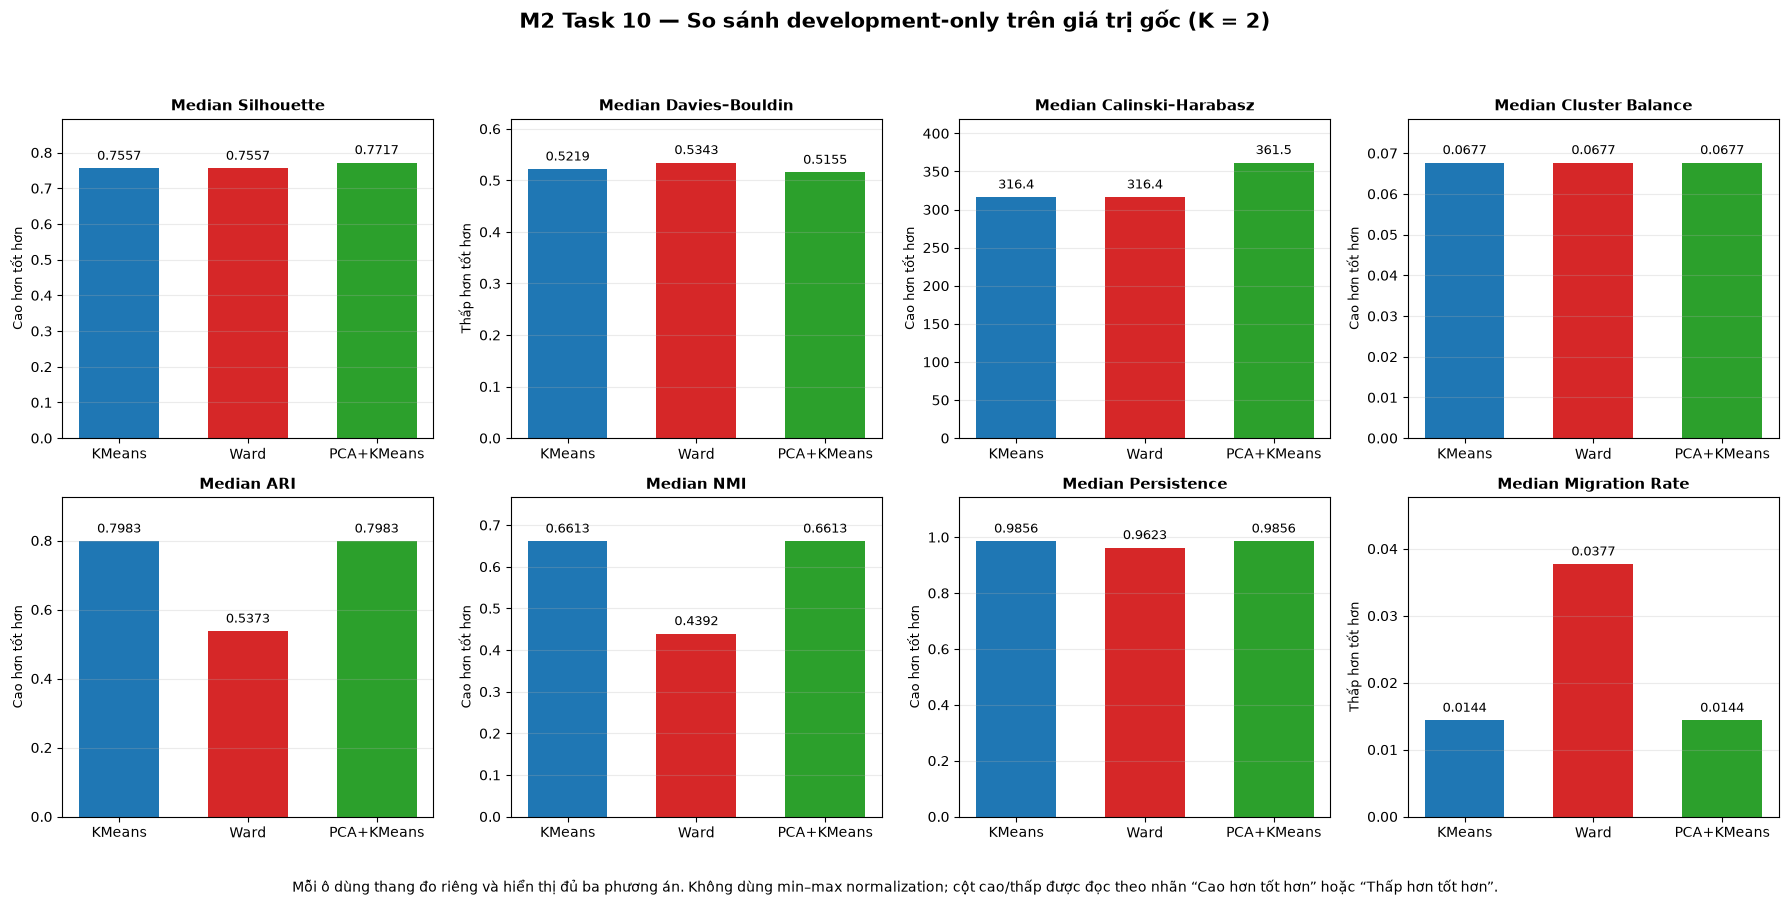

In [8]:
# Biểu đồ dùng giá trị gốc; mỗi ô có thang đo riêng để không làm mất cột có điểm chuẩn hóa bằng 0.
plot_frame = comparison.set_index('method').loc[list(METHODS)].copy()
plot_specs = [
    ('Median Silhouette', 'median_silhouette', 'Cao hơn tốt hơn', '.4f'),
    ('Median Davies–Bouldin', 'median_davies_bouldin', 'Thấp hơn tốt hơn', '.4f'),
    ('Median Calinski–Harabasz', 'median_calinski_harabasz', 'Cao hơn tốt hơn', '.1f'),
    ('Median Cluster Balance', 'median_cluster_balance', 'Cao hơn tốt hơn', '.4f'),
    ('Median ARI', 'median_ari', 'Cao hơn tốt hơn', '.4f'),
    ('Median NMI', 'median_nmi', 'Cao hơn tốt hơn', '.4f'),
    ('Median Persistence', 'median_persistence', 'Cao hơn tốt hơn', '.4f'),
    ('Median Migration Rate', 'median_migration_rate', 'Thấp hơn tốt hơn', '.4f'),
]
colors = {'KMeans_Baseline': '#1f77b4', 'Ward_Hierarchical': '#d62728', 'PCA_KMeans': '#2ca02c'}
short_labels = {'KMeans_Baseline': 'KMeans', 'Ward_Hierarchical': 'Ward', 'PCA_KMeans': 'PCA+KMeans'}

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for ax, (title, column, direction, number_format) in zip(axes.ravel(), plot_specs):
    values = plot_frame[column].astype(float)
    bars = ax.bar(
        [short_labels[method] for method in plot_frame.index],
        values,
        color=[colors[method] for method in plot_frame.index],
        width=0.62,
    )
    upper = max(values.max() * 1.16, values.max() + max(abs(values.max()) * 0.06, 0.01))
    ax.set_ylim(0, upper)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel(direction, fontsize=9)
    ax.grid(axis='y', alpha=0.25)
    for bar, value in zip(bars, values):
        ax.annotate(
            format(value, number_format),
            (bar.get_x() + bar.get_width() / 2, bar.get_height()),
            xytext=(0, 4), textcoords='offset points', ha='center', va='bottom', fontsize=9,
        )

fig.suptitle('M2 Task 10 — So sánh development-only trên giá trị gốc (K = 2)', fontsize=15, fontweight='bold', y=0.99)
fig.text(0.5, 0.01, 'Mỗi ô dùng thang đo riêng và hiển thị đủ ba phương án. Không dùng min–max normalization; cột cao/thấp được đọc theo nhãn “Cao hơn tốt hơn” hoặc “Thấp hơn tốt hơn”.', ha='center', fontsize=10)
fig.tight_layout(rect=(0, 0.05, 1, 0.95))
chart_path = OUTPUT_DIR / 'model_comparison_radar_or_bar.png'
fig.savefig(chart_path, dpi=200, bbox_inches='tight')
plt.show()


### Đóng băng mô hình và lập biên bản

Chỉ sau khi tính xong decision trace, notebook mới sao chép 15 JSON model của phương án thắng từ thư mục artifact nguồn. SHA-256 của từng file được lưu trong `model_file_manifest.json`; nếu thư mục đích đã chứa bộ model khác, notebook sẽ dừng và không ghi đè.

In [9]:
def format_metric(method: str, column: str) -> str:
    return f"{float(comparison.set_index('method').loc[method, column]):.6f}"

# Freeze the fitted development models only after the decision has been calculated.
source_model_dir = METHODS[selected_method]['task_dir'] / 'models'
source_models = sorted(source_model_dir.glob('????-??-??.json'))
assert len(source_models) == 15, f'{selected_method}: expected 15 fitted model files'
assert [path.stem for path in source_models] == EXPECTED_SNAPSHOTS, 'Model dates do not match development protocol'

if MODEL_TARGET.exists() and any(MODEL_TARGET.iterdir()):
    existing = sorted(MODEL_TARGET.glob('????-??-??.json'))
    if [path.name for path in existing] != [path.name for path in source_models] or any(sha256(MODEL_TARGET / path.name) != sha256(path) for path in source_models):
        raise RuntimeError('final_selected_model already contains a different frozen model set; refusing to overwrite it.')
else:
    MODEL_TARGET.mkdir(parents=True, exist_ok=True)
    for source in source_models:
        shutil.copy2(source, MODEL_TARGET / source.name)

model_manifest = {
    'selected_method': selected_method,
    'source_directory': str(source_model_dir.relative_to(REPO_ROOT)),
    'development_snapshots': EXPECTED_SNAPSHOTS,
    'files': [{'name': source.name, 'sha256': sha256(source)} for source in source_models],
}
with (MODEL_TARGET / 'model_file_manifest.json').open('w', encoding='utf-8') as handle:
    json.dump(model_manifest, handle, indent=2, ensure_ascii=False)

selection_rationale = (
    f"{selected_method} is selected after all methods passed the minimum-cluster-size sanity gate. "
    f"Its median Silhouette is {format_metric(selected_method, 'median_silhouette')} and median Davies-Bouldin is "
    f"{format_metric(selected_method, 'median_davies_bouldin')}. "
    + (f"The raw quality leader was {quality_leader}, but the absolute median-Silhouette gap versus KMeans is {occam_gap:.6f}, below the pre-specified 0.03 Occam threshold; KMeans is therefore preferred for its lower pipeline complexity and direct interpretation on the eight original features." if occam_applied else f"The quality leader remains selected because the KMeans comparison does not activate the pre-specified Occam threshold.")
)

rejection_rationales = {}
for method in comparators:
    row = comparison.set_index('method').loc[method]
    if method == quality_leader and occam_applied:
        rejection_rationales[method] = (
            f"Median Silhouette {float(row['median_silhouette']):.6f} exceeds KMeans by only {occam_gap:.6f}, below the 0.03 Occam threshold; "
            f"the {row['pipeline_complexity']} complexity pipeline is not selected over the simpler KMeans pipeline."
        )
    else:
        rejection_rationales[method] = (
            f"Median Silhouette {float(row['median_silhouette']):.6f} and median Davies-Bouldin {float(row['median_davies_bouldin']):.6f} "
            f"do not prevail under the ordered development-only decision criteria."
        )

final_decision = {
    'decision_timestamp': datetime.now(timezone.utc).replace(microsecond=0).isoformat(),
    'selected_method': selected_method,
    'comparator_methods': comparators,
    'global_k': 2,
    'decision_criteria_rank': [
        '1. Median Silhouette (Primary)',
        '2. Median Davies-Bouldin (Confirmation / Tie-breaker)',
        '3. Cluster Balance (Sanity check)',
        '4. Temporal Stability (ARI / Migration)',
        "5. Occam's Razor (Simplicity & direct interpretability)",
    ],
    'selection_rationale': selection_rationale,
    'rejection_rationales': rejection_rationales,
    'frozen_artifacts_manifest': {
        'comparison_table': 'M2/artifacts/m2-evaluation/methodology_comparison.csv',
        'selected_model_directory': 'M2/models/final_selected_model/',
    },
    'status': 'FROZEN_FOR_HOLDOUT',
}
decision_path = OUTPUT_DIR / 'final_method_decision.json'
with decision_path.open('w', encoding='utf-8') as handle:
    json.dump(final_decision, handle, indent=2, ensure_ascii=False)

assert final_decision['status'] == 'FROZEN_FOR_HOLDOUT'
assert len(final_decision['comparator_methods']) == 2
assert len(list(MODEL_TARGET.glob('????-??-??.json'))) == 15
final_decision


{'decision_timestamp': '2026-10-03T15:05:39+00:00',
 'selected_method': 'KMeans_Baseline',
 'comparator_methods': ['Ward_Hierarchical', 'PCA_KMeans'],
 'global_k': 2,
 'decision_criteria_rank': ['1. Median Silhouette (Primary)',
  '2. Median Davies-Bouldin (Confirmation / Tie-breaker)',
  '3. Cluster Balance (Sanity check)',
  '4. Temporal Stability (ARI / Migration)',
  "5. Occam's Razor (Simplicity & direct interpretability)"],
 'selection_rationale': 'KMeans_Baseline is selected after all methods passed the minimum-cluster-size sanity gate. Its median Silhouette is 0.755722 and median Davies-Bouldin is 0.521899. The raw quality leader was PCA_KMeans, but the absolute median-Silhouette gap versus KMeans is 0.015945, below the pre-specified 0.03 Occam threshold; KMeans is therefore preferred for its lower pipeline complexity and direct interpretation on the eight original features.',
 'rejection_rationales': {'Ward_Hierarchical': 'Median Silhouette 0.755722 and median Davies-Bouldin 0

### Kiểm chứng cuối và điều kiện bàn giao

Ô cuối kiểm tra schema 12 cột, trạng thái `FROZEN_FOR_HOLDOUT`, biểu đồ, report và đủ 15 model. Chỉ khi toàn bộ assert này qua thì Task 10 mới được xem là hoàn thành; Task 11 sau đó chỉ được phép chạy mô hình đã freeze.

### Luận điểm đã đóng băng trong notebook

**Vì sao chọn KMeans?** KMeans và Ward hòa ở Silhouette (`0.755722`), nhưng KMeans có DB thấp hơn, ARI cao hơn và Migration thấp hơn. PCA + KMeans nhỉnh hơn về Silhouette (`0.771666`), nhưng hơn KMeans chỉ `0.015945`, thấp hơn ngưỡng Occam `0.03`; Balance và toàn bộ chỉ số temporal bằng nhau. KMeans được chọn vì đơn giản hơn mà không bỏ lỡ một cải thiện đủ lớn đã khóa trước.

**Vì sao loại Ward và PCA?** Ward không mang lại lợi thế nào bù cho pipeline phức tạp hơn. PCA là comparator mạnh nhất về hình học, nhưng lợi thế nhỏ không cải thiện độ ổn định theo thời gian; chọn PCA sẽ phá vỡ quy tắc Occam đã định trước.

**Freeze nghĩa là gì?** Khóa KMeans, `K=2`, 8 feature, universe rule, Robust Scaling per-snapshot và 15 model JSON. Final Holdout chỉ kiểm định mô hình này; không được đổi thuật toán, K, feature, scaler hoặc PCA theo kết quả holdout.

In [10]:
# Cập nhật luận điểm định lượng trong decision JSON; không xuất báo cáo Markdown riêng.
kmeans = comparison.set_index('method').loc['KMeans_Baseline']
ward = comparison.set_index('method').loc['Ward_Hierarchical']
pca = comparison.set_index('method').loc['PCA_KMeans']
final_decision['selection_rationale'] = (
    f'KMeans_Baseline được chọn sau khi cả ba phương án vượt sanity check. So với Ward_Hierarchical, KMeans có cùng Median Silhouette={float(kmeans["median_silhouette"]):.6f} nhưng DB thấp hơn ({float(kmeans["median_davies_bouldin"]):.6f} so với {float(ward["median_davies_bouldin"]):.6f}), ARI cao hơn ({float(kmeans["median_ari"]):.6f} so với {float(ward["median_ari"]):.6f}) và Migration thấp hơn ({float(kmeans["median_migration_rate"]):.6f} so với {float(ward["median_migration_rate"]):.6f}). So với PCA_KMeans, PCA có Median Silhouette cao hơn ({float(pca["median_silhouette"]):.6f} so với {float(kmeans["median_silhouette"]):.6f}) và DB thấp hơn, nhưng chênh lệch Silhouette chỉ {occam_gap:.6f}, nhỏ hơn ngưỡng Occam 0.03; Balance và bốn chỉ số temporal của hai phương án bằng nhau. KMeans được ưu tiên nhờ pipeline Low complexity và diễn giải trực tiếp trên 8 feature gốc.'
)
final_decision['rejection_rationales'] = {
    'Ward_Hierarchical': (
        f'Có cùng Median Silhouette={float(ward["median_silhouette"]):.6f} và Balance={float(ward["median_cluster_balance"]):.6f} với KMeans, nhưng DB cao hơn ({float(ward["median_davies_bouldin"]):.6f}), ARI thấp hơn ({float(ward["median_ari"]):.6f}) và Migration cao hơn ({float(ward["median_migration_rate"]):.6f}); không có lợi thế để đánh đổi với pipeline Medium complexity.'
    ),
    'PCA_KMeans': (
        f'Dẫn đầu nhẹ về Silhouette={float(pca["median_silhouette"]):.6f} và DB={float(pca["median_davies_bouldin"]):.6f}, nhưng hơn KMeans chỉ {occam_gap:.6f} Silhouette, thấp hơn ngưỡng Occam 0.03; Balance, ARI, NMI, Persistence và Migration không tốt hơn KMeans. Pipeline High complexity không được ưu tiên.'
    ),
}
with decision_path.open('w', encoding='utf-8') as handle:
    json.dump(final_decision, handle, indent=2, ensure_ascii=False)


In [11]:
# Final, fail-closed verification of Task 10 outputs.
assert comparison_path.exists() and pd.read_csv(comparison_path).columns.tolist() == expected_columns
assert decision_path.exists() and json.loads(decision_path.read_text(encoding='utf-8'))['status'] == 'FROZEN_FOR_HOLDOUT'
assert chart_path.exists() and chart_path.stat().st_size > 0
assert len(list(MODEL_TARGET.glob('????-??-??.json'))) == 15
print('TASK 10 VERIFIED: development-only comparison completed and final method frozen.')


TASK 10 VERIFIED: development-only comparison completed and final method frozen.
